# Mini Exploratory Data Analysis (EDA) on Titanic Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

df = pd.read_csv("/Titanic-Dataset.csv")
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '/Titanic-Dataset.csv'

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data Cleaning

In this step, the dataset is cleaned by handling missing values and removing irrelevant columns to prepare the data for analysis.

**Tasks Performed:**
- Filled missing values in the **Age** column using the mean age.
- Removed the **Cabin** column due to a large number of missing values.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df = df.drop(columns=["Cabin"])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Thus,

- Missing values in the **Age** and **Embarked** columns were successfully handled.
- The **Cabin** column was removed because it contained a large number of missing values.
- The dataset is now free of missing values.

## Analysis 1: Survival Rate by Age Group

In [ ]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,19,35,60,100],
    labels=["Child","Teen","Adult","Middle Age","Senior"]
)

age_survival = df.groupby("AgeGroup", observed=False)["Survived"].mean() * 100
age_survival

,Survived
AgeGroup,
Child,57.971014
Teen,41.052632
Adult,35.294118
Middle Age,40.000000
Senior,22.727273


## Visualization

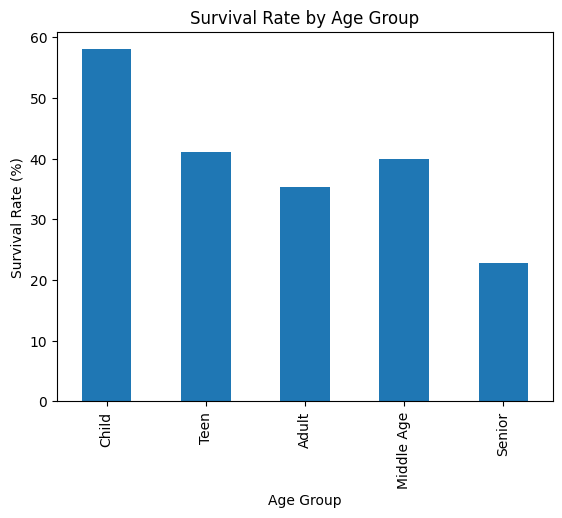

In [ ]:
age_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.show()

- Children had a relatively higher survival rate.
- Adults showed a moderate survival rate.
- Senior passengers had a comparatively lower survival rate.

## Analysis 2: Survival Rate by Embarkation Port

In [ ]:
port_survival = df.groupby("Embarked")["Survived"].mean() * 100
port_survival

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.900929


## Visualization

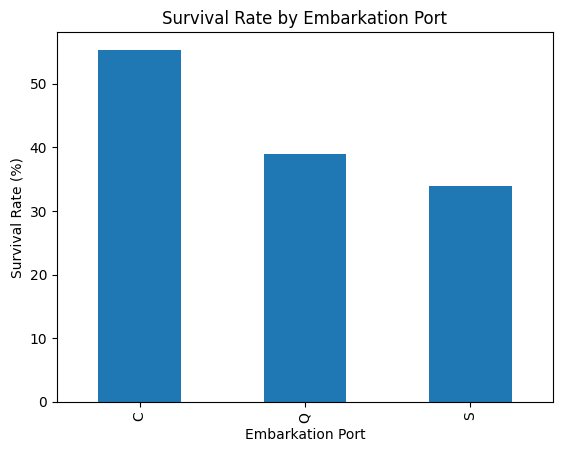

In [ ]:
port_survival.plot(kind="bar")
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.show()

- Survival rates varied across embarkation ports.
- Some embarkation ports had noticeably higher survival percentages than others.

## Analysis 3: Survival Rate by Family Size

In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"]
family_survival = df.groupby("FamilySize")["Survived"].mean() * 100
family_survival

,Survived
FamilySize,
0,30.353818
1,55.279503
2,57.843137
3,72.413793
4,20.000000
5,13.636364
6,33.333333
7,0.000000
10,0.000000


## Visualization

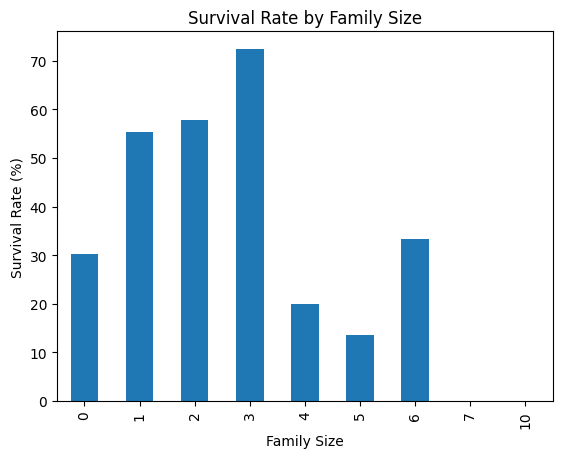

In [ ]:
family_survival.plot(kind="bar")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.show()

- Passengers travelling with small families had higher survival rates.
- Passengers travelling alone or with very large families had comparatively lower survival rates.

# Conclusion

In this project, a Mini Exploratory Data Analysis (EDA) was performed on the Titanic dataset. The dataset was cleaned by handling missing values and removing the irrelevant **Cabin** column to improve data quality.

The analysis showed that:
- Children had the highest survival rate, while senior passengers had the lowest.
- Survival rates varied across different embarkation ports.
- Passengers travelling with small families had better survival chances compared to those travelling alone or in very large families.